In [1]:
from ModularCirc.Models.KMM_PP_NRC_parameters import KMM_PP_NRC_parameters
# from ModularCirc.Models.KMM_PP_NRC import KMM_PP_NRC
from ModularCirc.Models.KMM_NRC import KMM_NRC as KMM_PP_NRC
from ModularCirc.Solver import Solver

import numpy as np
import scipy as sp

In [2]:
time_setup_dict = {
            'name': 'TimeTest',
            'ncycles': 40,
            'tcycle': 1.0,
            'dt': 0.001,
            'export_min': 1
        }

In [3]:
parobj = KMM_PP_NRC_parameters()
# parobj.set_chamber_comp('ra', k_pas=0.003)
# parobj.set_chamber_comp('rv', k_pas=0.003, E_act=2.0)

tr = 0.35
td = 0.15

# parobj.set_rlc_comp('pas', l = 1e-10)
# parobj.set_rlc_comp(
#     'pas', 
    # c = 1.0, 
    # l = 0.0
# )

parobj.set_chamber_comp('rv', tr=tr, td=tr+td)
parobj.set_chamber_comp('lv', tr=tr, td=tr+td)

fact = 2.
c_ref = 1.  * fact
r = 0.21 / fact
p1 = 27.0
# p2 = 22.89
p2 = 1.
p_crit = 10.0
# p1 = p_crit

# C = A_m * beta / pi -> A_m = C * pi / beta -> tau_joe = R * A_m = R * C * pi / beta
tau_Joe = r * c_ref * np.pi  * p2
print(f"tau_Joe = {tau_Joe:.4f} s")
print(f'tau (RC) = {r * c_ref:.4f} s')

# parobj.set_valve_comp('po', CQ=300)
# parobj.set_nonlinear_rc_comp('pat', c_ref=2., r=0.21, p1=p1, beta=1.0)
parobj.set_nonlinear_rc_comp('pat', c_ref=c_ref, r=r, p1=p1, p2=p2,
                             p_crit=p_crit, 
                             )

model = KMM_PP_NRC(time_setup_dict, parobj=parobj, suppress_printing=True)

solver = Solver(model)

tau_Joe = 0.6597 s
tau (RC) = 0.2100 s


In [4]:
solver.setup(suppress_output=True, method='LSODA', step=1)
solver.solve()
solver.converged

True

In [5]:
from ModularCirc.Analysis.BaseAnalysis import BaseAnalysis

In [6]:
ba = BaseAnalysis(model=model)

In [7]:
import matplotlib.pyplot as plt

In [8]:
# Computing the limit volume for pat
# (v - v_ref) / c_ref * beta**2.0 = pi / 2
# v = v_ref + c_ref * pi / (2 * beta**2.0)

print('Limit volume for pat:')
v_lim = c_ref * np.pi / (2 / p2**2.0)
print(f'v_lim = {v_lim:.2f} mL')


Limit volume for pat:
v_lim = 3.14 mL


127
(1000, 1)
(1000,)


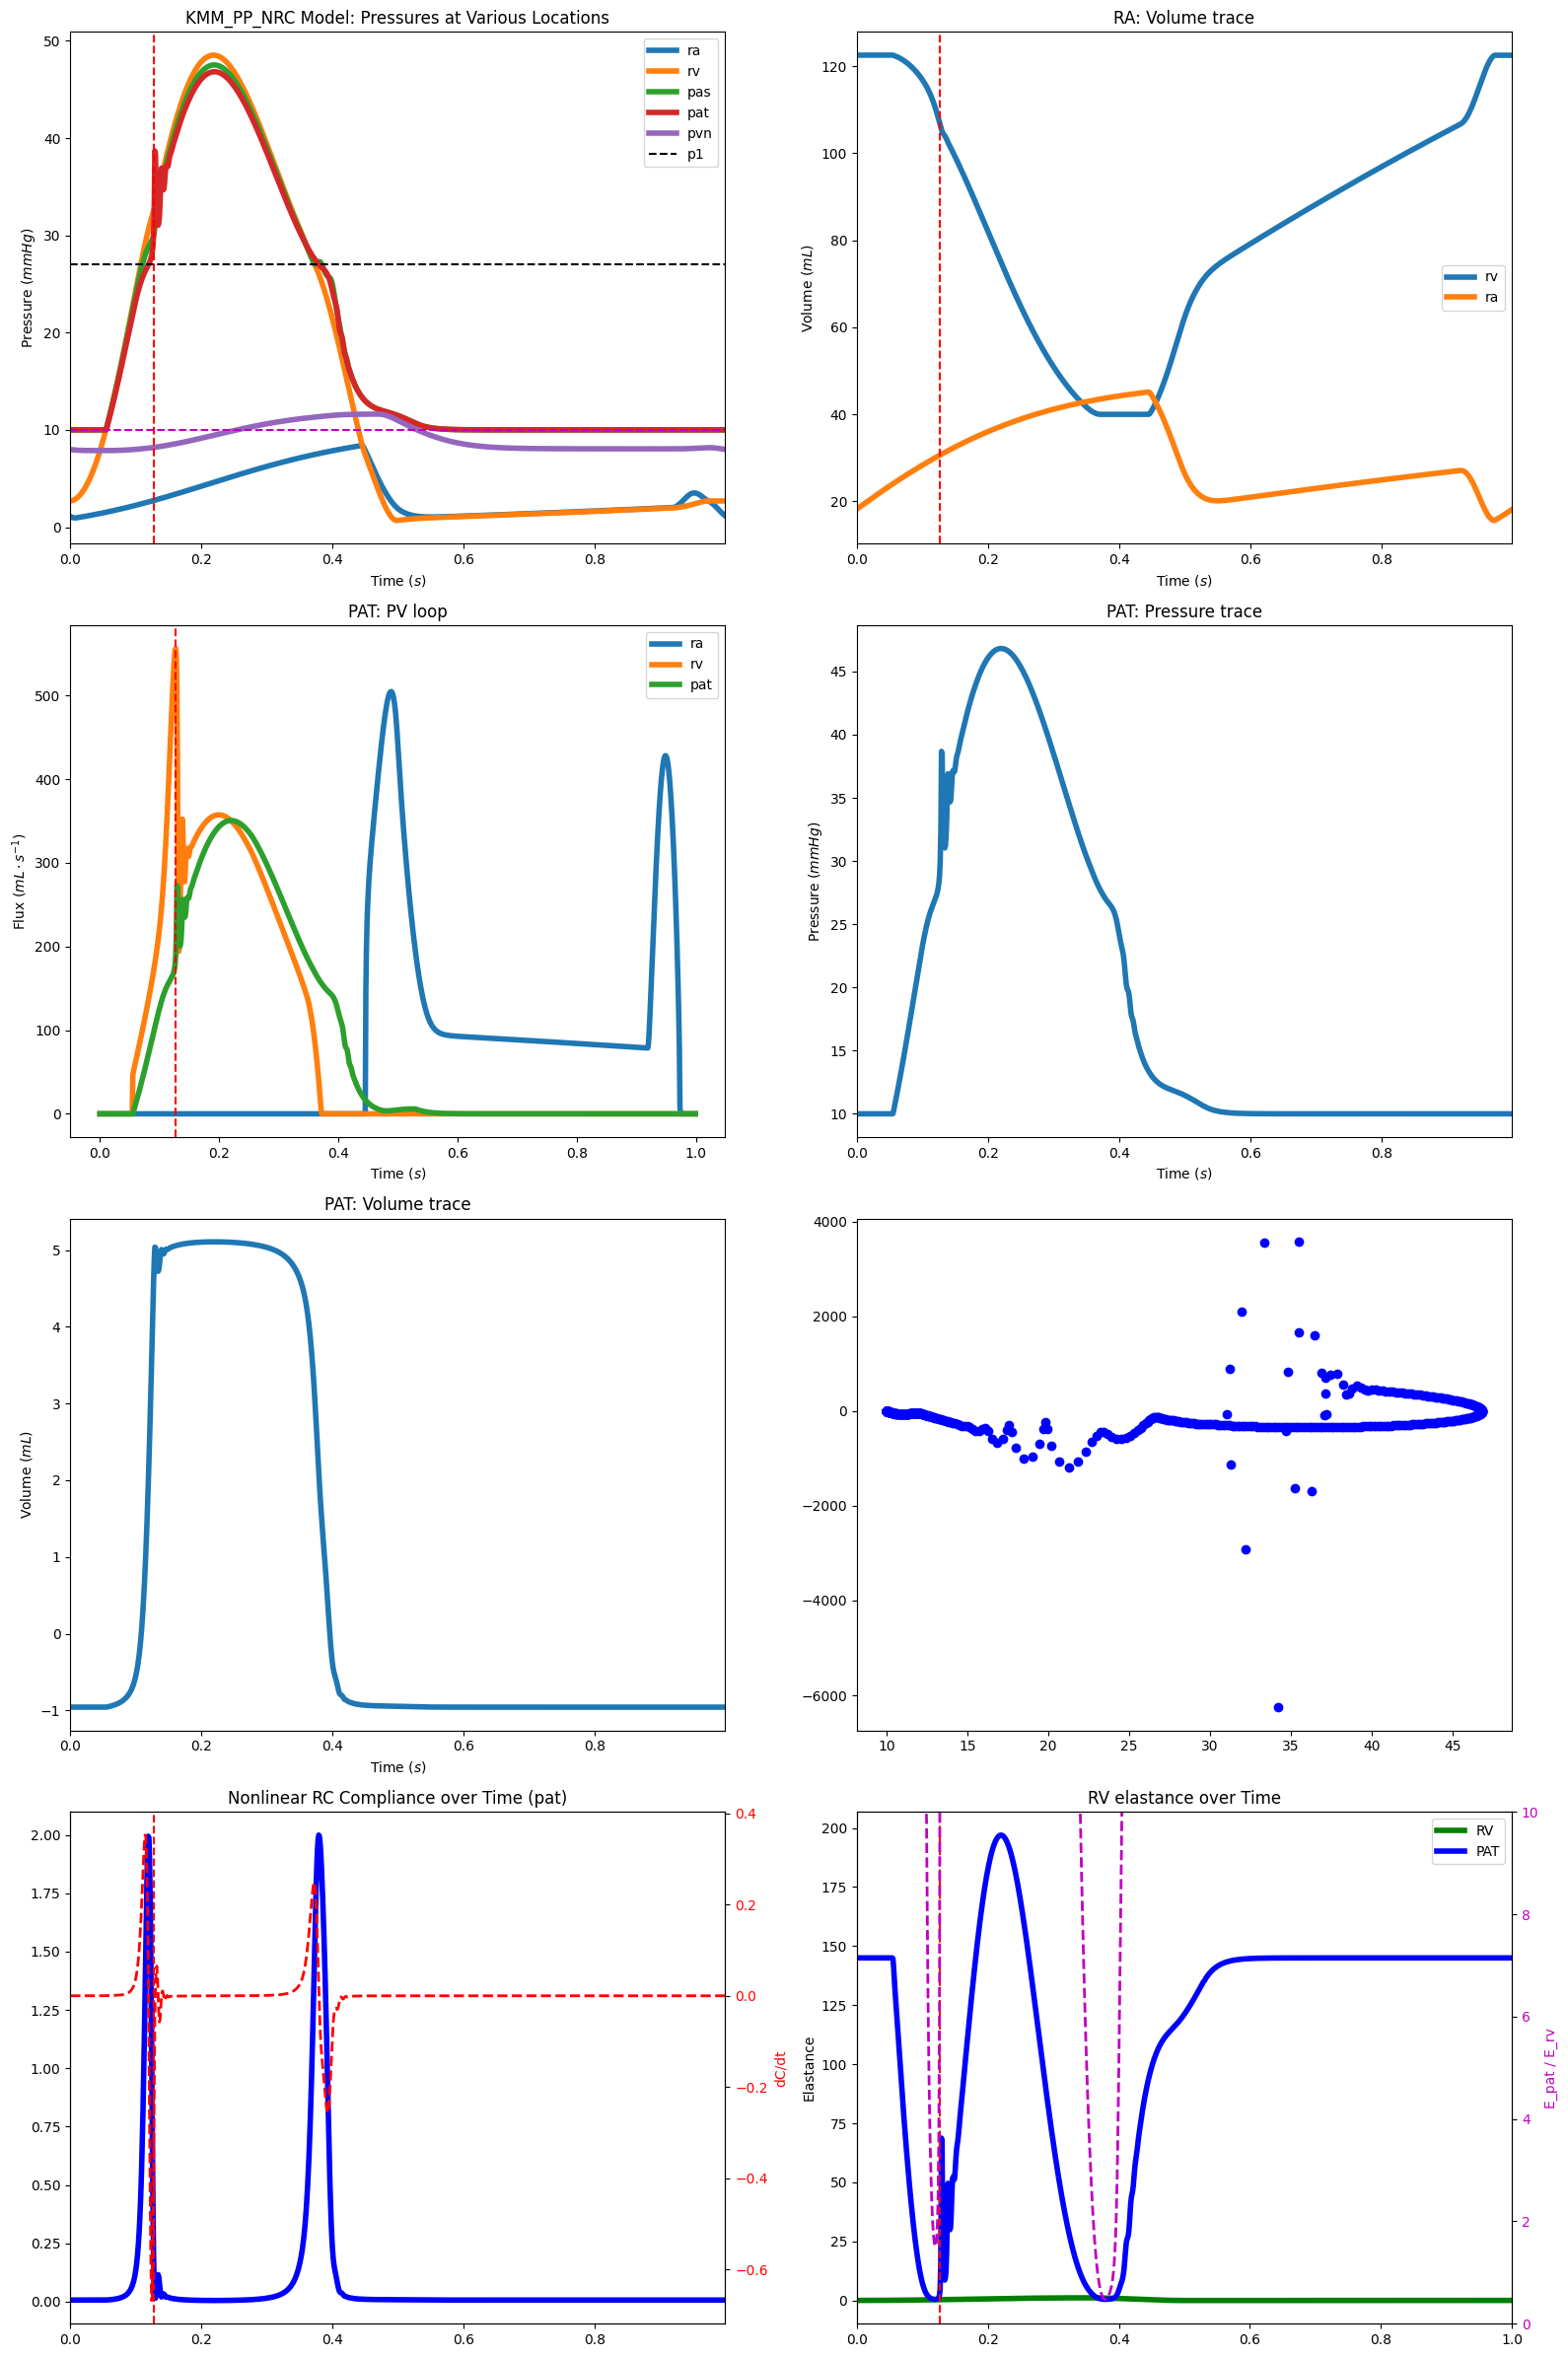

In [9]:
fig, ax = plt.subplots(ncols=2, nrows=4, figsize=(16, 24))
ax = ax.flatten()
ba.plot_t_p(component='ra', ax=ax[0])
ba.plot_t_p(component='rv', ax=ax[0])
ba.plot_t_p(component='pas', ax=ax[0])
ba.plot_t_p(component='pat', ax=ax[0])
ba.plot_t_p(component='pvn', ax=ax[0])
ax[0].axhline(y=p1, color='k', linestyle='--', label='p1')
ax[0].set_title('KMM_PP_NRC Model: Pressures at Various Locations')
ax[0].legend(['ra', 'rv'] + ['pas', 'pat', 'svn', 'p1'])
ax[0].legend()

ind = sp.signal.find_peaks(model.components['rv'].Q_o.values[ba.tind])[0][0]
print(ind)
ax[0].axvline(x=ba.tsym[ind], color='r', linestyle='--')
ax[0].axhline(y=p_crit, color='m', linestyle='--', label='p_crit')

ba.plot_t_v(component='rv', ax=ax[1])
ba.plot_t_v(component='ra', ax=ax[1])
ax[1].legend()
ax[1].axvline(x=ba.tsym[ind], color='r', linestyle='--')

ba.plot_t_q_out(component='ra', ax=ax[2])
ba.plot_t_q_out(component='rv', ax=ax[2])
ba.plot_t_q_out(component='pat', ax=ax[2])
ax[2].legend()
ax[2].axvline(x=ba.tsym[ind], color='r', linestyle='--')

# ba.plot_p_v_loop(component='pat', ax=ax[3])
ba.plot_t_p(component='pat', ax=ax[3])

ba.plot_t_v(component='pat', ax=ax[4], linestyle='-')

p = model.components['pat'].P.values[ba.tind]
dpdt =( np.roll(model.components['pat']._P_i.u.values[ba.tind], -1) - np.roll(model.components['pat']._P_i.u.values[ba.tind], 1) ) / model.time_object.dt
ind_min_dpdt = np.argmin(dpdt)
ax[5].plot(p[ind_min_dpdt:], dpdt[ind_min_dpdt:], 'o', color='b', linewidth=4)

p = model.components['pat'].P.values[ba.tind]
c = c_ref / (1 + p2**-2.0 * (p - p1) ** 2.0)
dcdt = np.roll(c, -1) - np.roll(c, 1) 
ax[6].plot(ba.tsym, c, color='b', linestyle='-', linewidth=4)
ax[6].set_xlim(ba.tsym[0], ba.tsym[-1])
ax[6].set_title('Nonlinear RC Compliance over Time (pat)')
ax[6].axvline(x=ba.tsym[ind], color='r', linestyle='--')

ax6_2 = ax[6].twinx()
ax6_2.plot(ba.tsym, dcdt, color='r', linestyle='--', linewidth=2)
ax6_2.set_ylabel('dC/dt', color='r')
ax6_2.tick_params(axis='y', labelcolor='r')

rv_v = model.components['rv'].V.values[ba.tind]
rv_q_i = model.components['rv']._Q_i.u.values[ba.tind]
rv_q_o = model.components['rv']._Q_o.u.values[ba.tind]
y_array = rv_v[:, np.newaxis]
print(y_array.shape)
print(ba.tind.shape)

model_rv_p = model.components['rv']._P_i._ode_sys_mapping['i_func']

rv_dpdv = np.zeros_like(ba.tsym, dtype=float)
for i, (t, y) in enumerate(zip(ba.tsym, y_array)):
    # Ensure y is C-contiguous for Cython function
    y_contiguous = np.ascontiguousarray(y)
    rv_dpdv[i] = model_rv_p(t, y_contiguous + 1e-6)
    rv_dpdv[i] -= model_rv_p(t, y_contiguous - 1e-6)
    rv_dpdv[i] /= (2e-6)
    # print(f't={t}, rv_p={rv_p}')

           
ax[7].plot(ba.tsym, rv_dpdv, color='g', linestyle='-', linewidth=4, label='RV')
ax[7].plot(ba.tsym, 1.0 / c, color='b', linestyle='-', linewidth=4, label='PAT')
ax[7].set_ylabel('Elastance')
ax[7].set_xlim(0, 1.)
ax[7].set_title('RV elastance over Time')
ax[7].axvline(x=ba.tsym[ind], color='r', linestyle='--')
ax[7].legend()

ax7_2 = ax[7].twinx()
ax7_2.plot(ba.tsym, 1 / (c * rv_dpdv), color='m', linestyle='--', linewidth=2)
ax7_2.tick_params(axis='y', labelcolor='m')
ax7_2.set_ylabel('E_pat / E_rv', color='m')
ax7_2.set_ylim(0, 10.)

plt.tight_layout()
plt.show()

In [10]:
ba.compute_cardiac_output('rv')

np.float64(4950.162490156965)

123
(1000, 1)
(1000,)


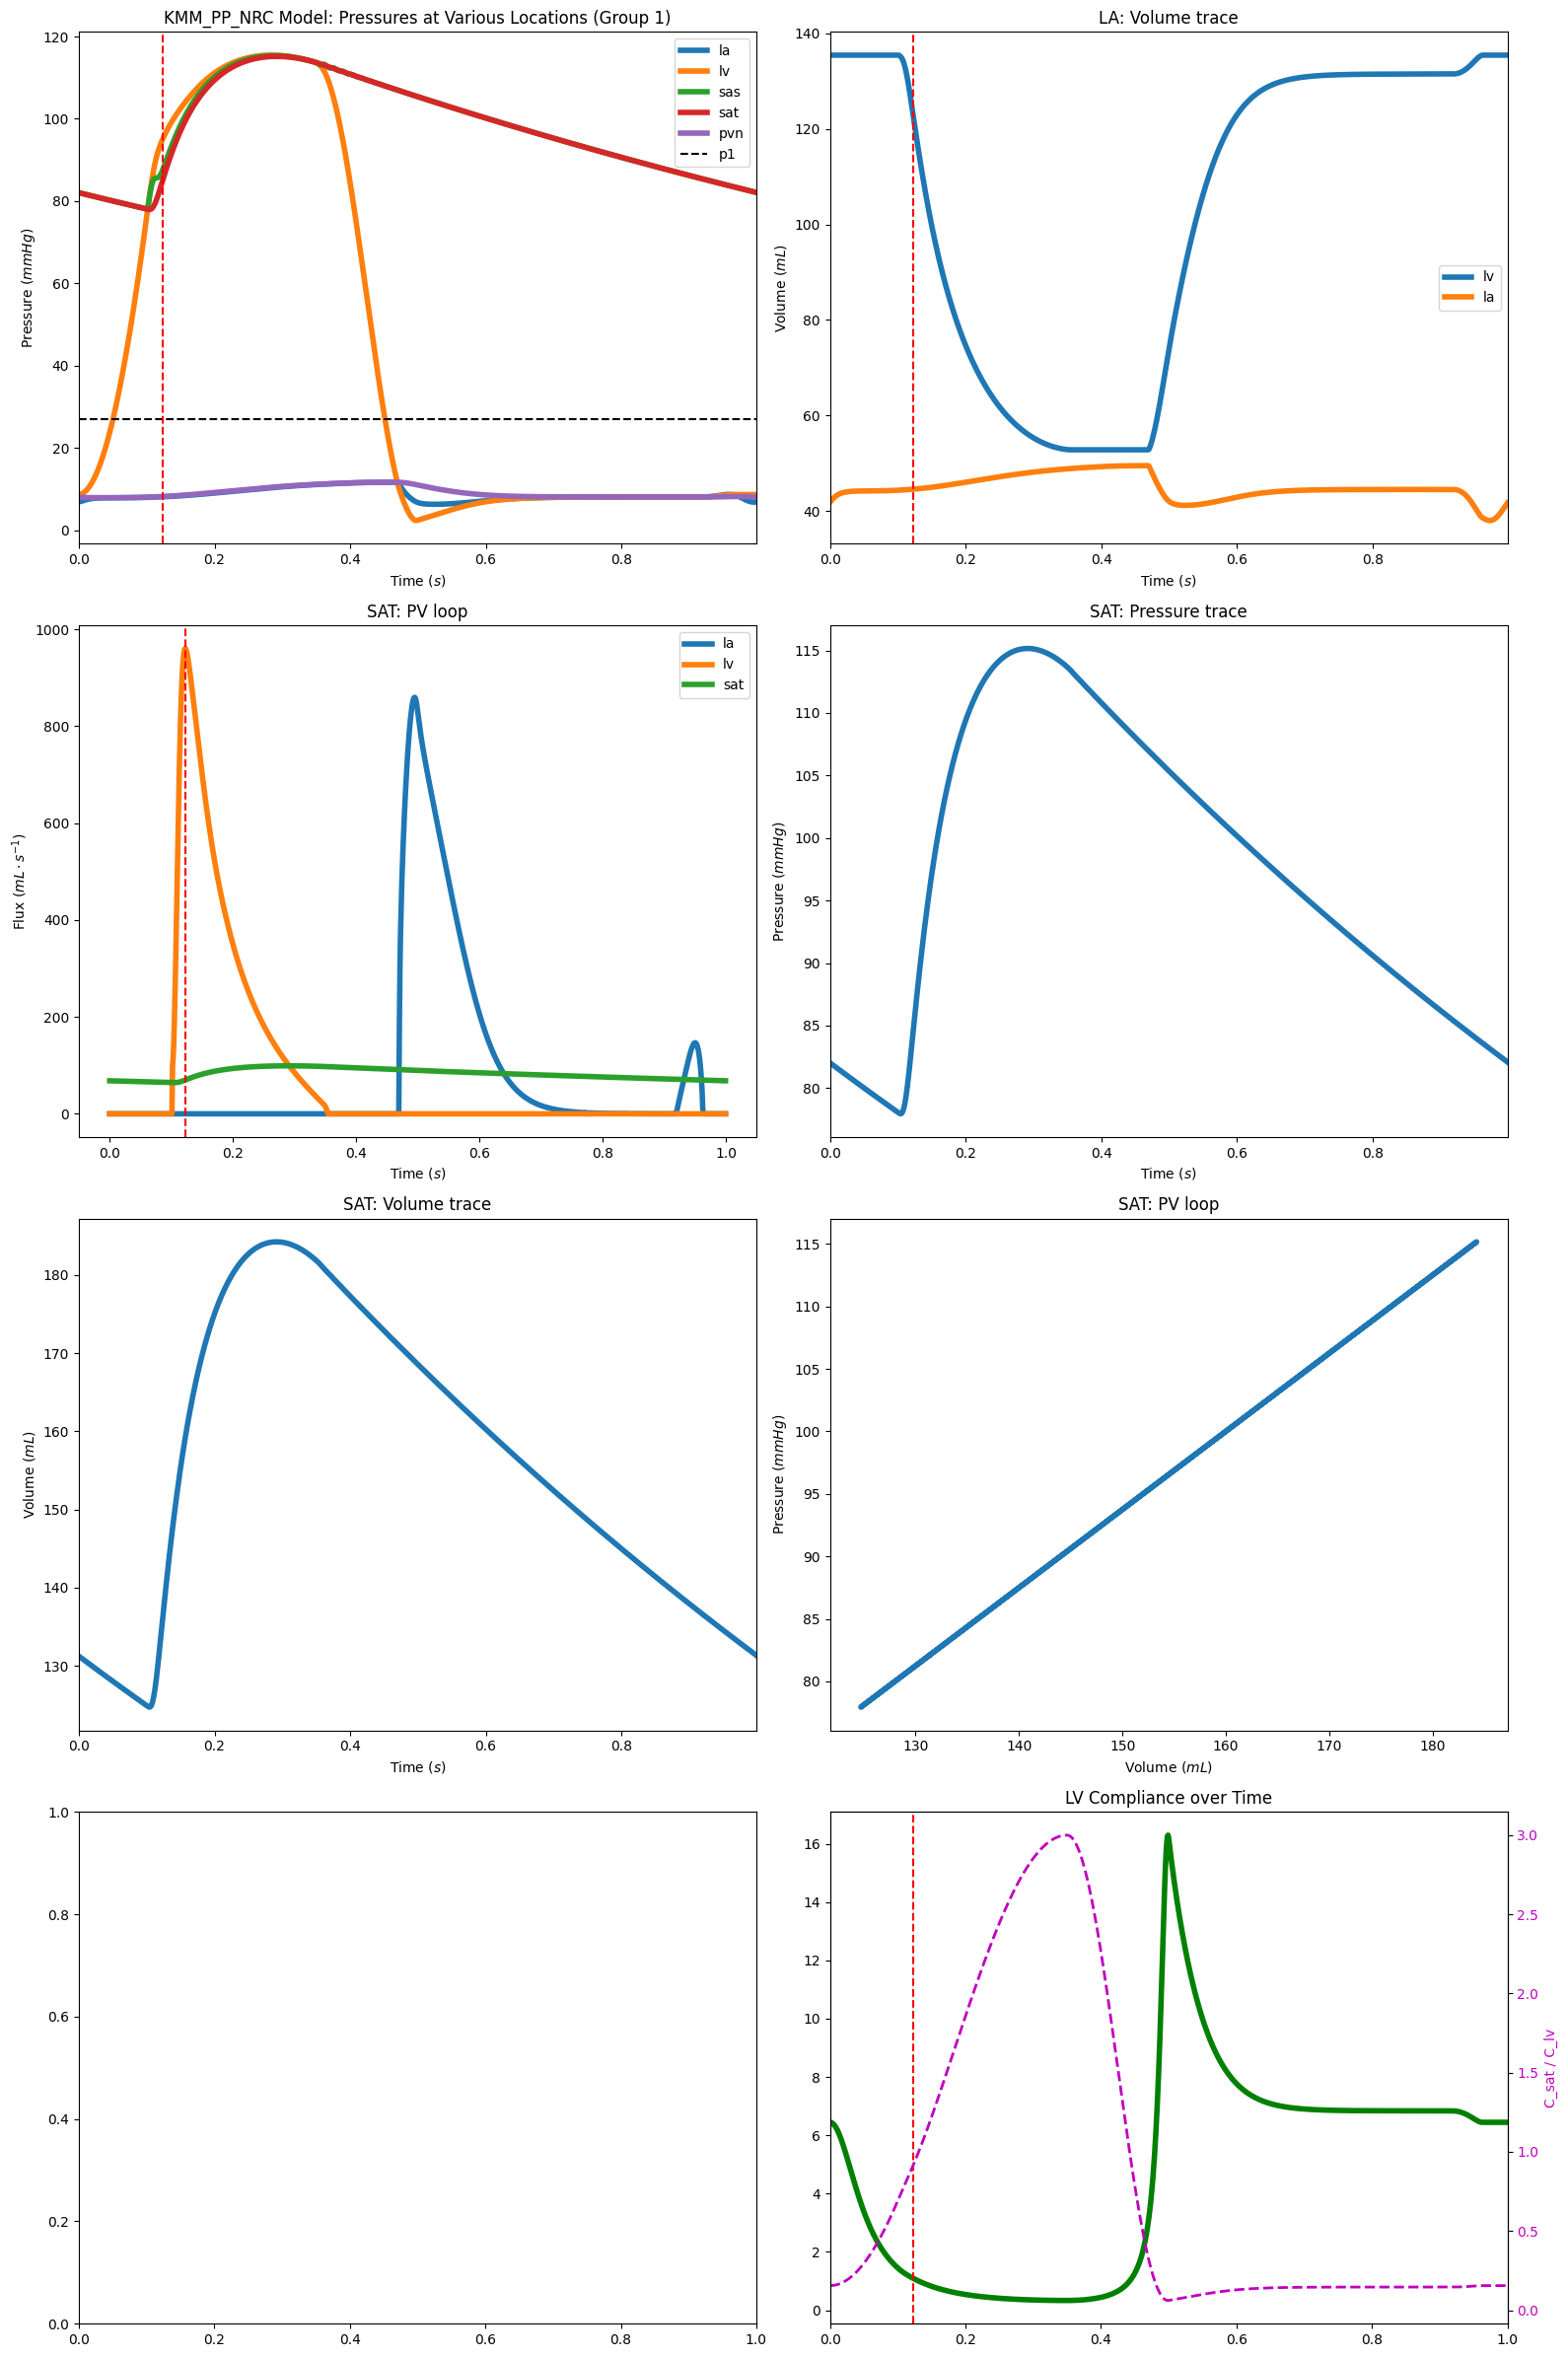

In [11]:
fig, ax = plt.subplots(ncols=2, nrows=4, figsize=(16, 24))
ax = ax.flatten()
ba.plot_t_p(component='la', ax=ax[0])
ba.plot_t_p(component='lv', ax=ax[0])
ba.plot_t_p(component='sas', ax=ax[0])
ba.plot_t_p(component='sat', ax=ax[0])
ba.plot_t_p(component='pvn', ax=ax[0])
ax[0].axhline(y=p1, color='k', linestyle='--', label='p1')
ax[0].set_title('KMM_PP_NRC Model: Pressures at Various Locations (Group 1)')
ax[0].legend(['la', 'lv', 'sas', 'sat', 'pvn', 'p1'])
ax[0].legend()

ind = sp.signal.find_peaks(model.components['lv'].Q_o.values[ba.tind])[0][0]
print(ind)
ax[0].axvline(x=ba.tsym[ind], color='r', linestyle='--')

ba.plot_t_v(component='lv', ax=ax[1])
ba.plot_t_v(component='la', ax=ax[1])
ax[1].legend()
ax[1].axvline(x=ba.tsym[ind], color='r', linestyle='--')

ba.plot_t_q_out(component='la', ax=ax[2])
ba.plot_t_q_out(component='lv', ax=ax[2])
ba.plot_t_q_out(component='sat', ax=ax[2])
ax[2].legend()
ax[2].axvline(x=ba.tsym[ind], color='r', linestyle='--')

ba.plot_t_p(component='sat', ax=ax[3])

ba.plot_t_v(component='sat', ax=ax[4], linestyle='-')

ba.plot_p_v_loop(component='sat', ax=ax[5])


lv_v = model.components['lv'].V.values[ba.tind]
lv_q_i = model.components['lv']._Q_i.u.values[ba.tind]
lv_q_o = model.components['lv']._Q_o.u.values[ba.tind]
y_array = lv_v[:, np.newaxis]
print(y_array.shape)
print(ba.tind.shape)

model_lv_p = model.components['lv']._P_i._ode_sys_mapping['i_func']

lv_dpdv = np.zeros_like(ba.tsym, dtype=float)
for i, (t, y) in enumerate(zip(ba.tsym, y_array)):
    # Ensure y is C-contiguous for Cython function
    y_contiguous = np.ascontiguousarray(y)
    lv_dpdv[i] = model_lv_p(t, y_contiguous + 1e-6)
    lv_dpdv[i] -= model_lv_p(t, y_contiguous - 1e-6)
    lv_dpdv[i] /= (2e-6)
    # print(f't={t}, lv_p={lv_p}')

           
ax[7].plot(ba.tsym, 1.0 / lv_dpdv, color='g', linestyle='-', linewidth=4)
ax[7].set_xlim(0, 1.)
ax[7].set_title('LV Compliance over Time')
ax[7].axvline(x=ba.tsym[ind], color='r', linestyle='--')


ax7_2 = ax[7].twinx()
ax7_2.plot(ba.tsym, lv_dpdv, color='m', linestyle='--', linewidth=2)
ax7_2.tick_params(axis='y', labelcolor='m')
ax7_2.set_ylabel('C_sat / C_lv', color='m')

plt.tight_layout()
plt.show()


108.70898005776228 31.556538491599525


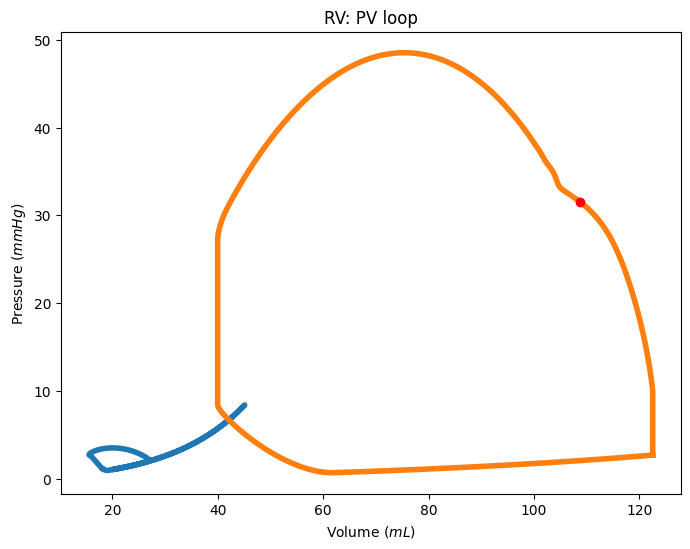

In [12]:
fig, ax = plt.subplots(figsize=(8, 6))
ba.plot_p_v_loop(component='ra', ax=ax)
ba.plot_p_v_loop(component='rv', ax=ax)

ax.plot(model.components['rv'].V[ba.tind[ind]], model.components['rv'].P[ba.tind[ind]], 'ro')

print(model.components['rv'].V[ba.tind[ind]], model.components['rv'].P[ba.tind[ind]])

<Axes: title={'center': 'LV: PV loop'}, xlabel='Volume ($mL$)', ylabel='Pressure ($mmHg$)'>

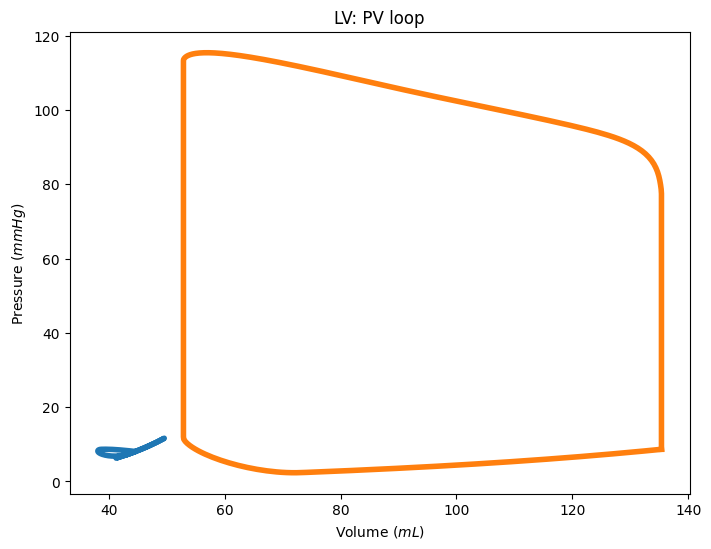

In [13]:
fig, ax = plt.subplots(figsize=(8, 6))
ba.plot_p_v_loop(component='la', ax=ax)
ba.plot_p_v_loop(component='lv', ax=ax)

In [14]:
import numpy as np
import matplotlib.pyplot as plt